**Exploratory data analysis**

In [1]:
# Importing libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [2]:
# Loading the data.
df = pd.read_csv("Crop_recommendation.csv")

In [3]:
# Viewing our data.
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


<span style="color:white">
The data is already preprocessed via a pipeline I developed. Duplicates as well as missing values or any inconsistencies have been checked and the data is ready for EDA or further preprocesing in preparation for ML tasks.
</span>

In [5]:
# Dataset shape and general information
df['P'].min()

5

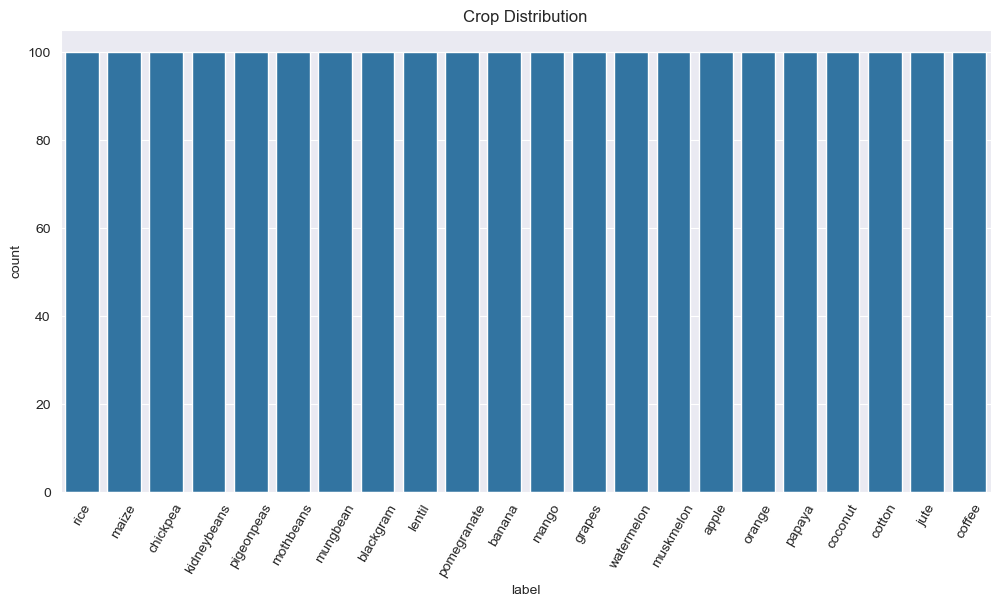

In [40]:
# Investigating dataset balance on target variable.
df['label'].value_counts(normalize=True)
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="label")
plt.xticks(rotation=60)
plt.title("Crop Distribution")
plt.show()

In [41]:
# Corrrelation matrix.
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


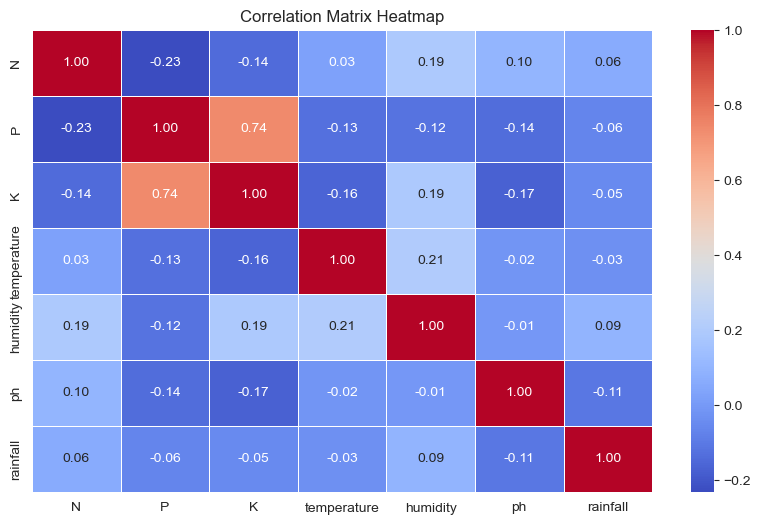

In [42]:
# Correlatiom heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
sns.set_style('darkgrid')
plt.show()

### Correlation Matrix Analysis

- The correlation matrix shows the pairwise correlations between the numerical features in the dataset:

- **Strong positive correlation**: P and K (0.74), indicating these nutrients are often present together.
- **Moderate correlations**: Humidity with temperature (0.21) and rainfall (0.09).
- **Weak or negative correlations**: Most other pairs, such as N with P (-0.23) and temperature with rainfall (-0.03).
- Overall, features like rainfall and humidity appear to have some influence on crop suitability, aligning with the feature importance results.

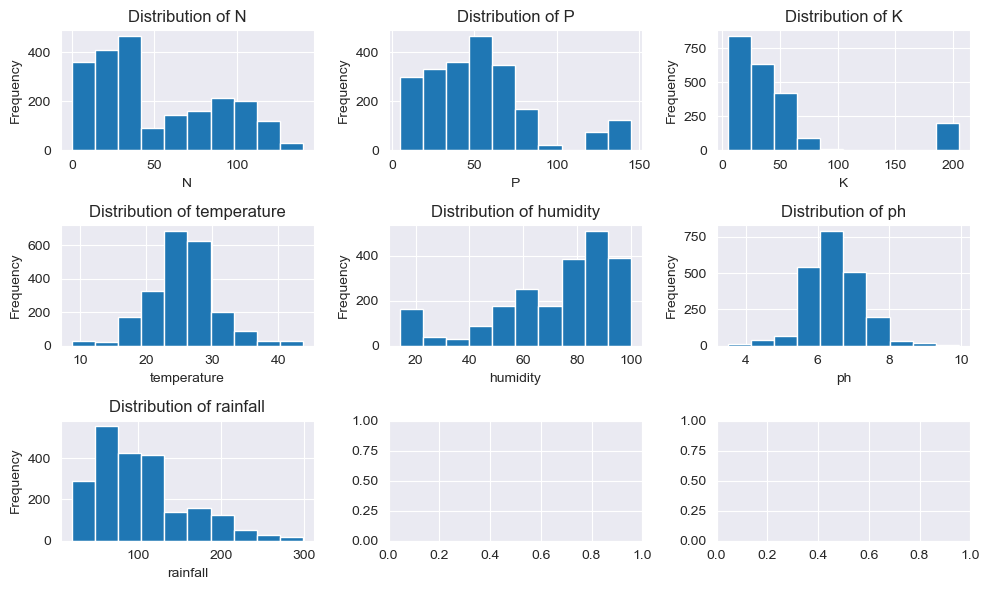

In [43]:
# Using subplots to visualize distribution of features.
features = df.drop(columns=['label'])
fig, ax = plt.subplots(3 ,3 ,figsize=(10,6))
ax = ax.flatten()
for i, feature in enumerate(features):
    ax[i].hist(df[feature], bins=10)
    ax[i].set_xlabel(f"{feature}")
    ax[i].set_ylabel("Frequency")
    ax[i].set_title(f"Distribution of {feature}")

for j in range(len(features), len(ax)):
    fig.delaxes(ax[j])


sns.set_style("darkgrid")
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info">
<b>Info:</b> From the histograms, the distribution of some features is clearly uneven necessitating the 
computing of skewness to determine suitable candidates for log transformation which will make the model 
more stable.
</div>

In [44]:
# Skewness computation.
print("====Skewness for each feature====")
for col in features:
    print(f"{col}: {round(df[col].skew(), 3)}")

print("==================================")


====Skewness for each feature====
N: 0.51
P: 1.011
K: 2.375
temperature: 0.185
humidity: -1.092
ph: 0.284
rainfall: 0.966


### Skewness Analysis for Feature Distributions

The skewness values for each feature are as follows (computed from the dataset):

#### Implications for Tree-Based Models (Random Forest)
Tree-based models, such as Random Forest, are generally robust to skewed distributions because they rely on splitting data at various thresholds rather than assuming normality or linear relationships. High skewness (e.g., K at 1.820, indicating right-skewed) or moderate skewness (e.g., P at 1.010, rainfall at 0.965) does not significantly impact performance, as these models can handle non-normal data effectively. No transformations (e.g., log or Box-Cox) are typically necessary, allowing the model to focus on feature importance (e.g., rainfall and humidity are top contributors here). This aligns with the observed feature importances, where skewed features like rainfall still rank highly.

#### Implications for Linear Regression (for Comparison)
Linear regression assumes normality of residuals and can be sensitive to skewed predictors, potentially leading to biased coefficients or heteroscedasticity. Features with high skewness (e.g., K at 1.820, P at 1.010) may violate assumptions, suggesting log transformation to stabilize variance and improve model stability. Near-symmetric features (e.g., temperature at 0.184, humidity at -0.091) are less concerning. However, given the correlations (e.g., strong P-K link), multicollinearity could compound issues. For comparison, evaluate metrics like R² and RMSE before/after transformations, but tree models may outperform due to their flexibility with skewed data. Overall, skewness highlights potential preprocessing needs for linear models but is not a barrier for trees.

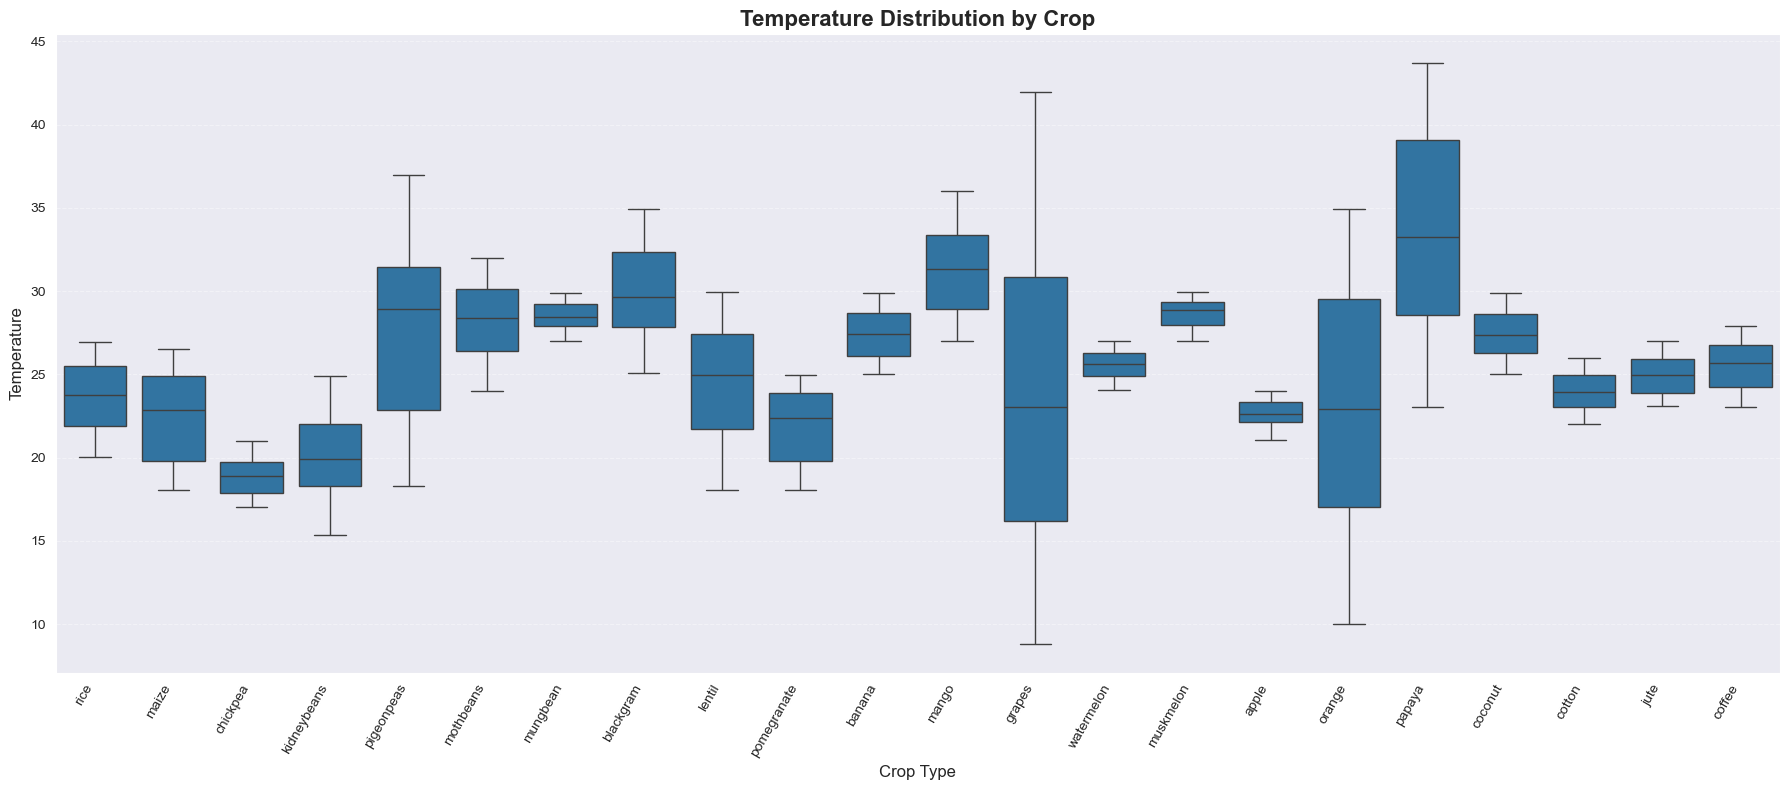

In [45]:
plt.figure(figsize=(18, 8))
sns.boxplot(
    x='label',
    y='temperature',
    data=df
)
plt.xticks(rotation=60, ha='right')
plt.title(f"Temperature Distribution by Crop", fontsize=16, fontweight='bold')
plt.xlabel("Crop Type", fontsize=12)
plt.ylabel(f"Temperature", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

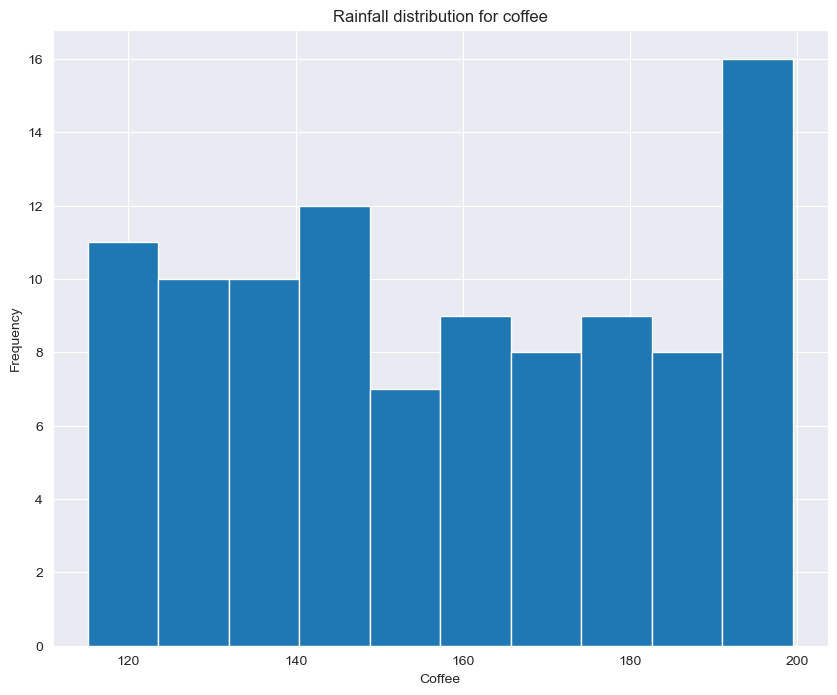

In [46]:
# Rainfall distribution for the coffee crop.
coffee = df[df['label'] == 'coffee']
plt.figure(figsize=(10,8))
plt.title("Rainfall distribution for coffee")
plt.hist(coffee['rainfall'], bins=10)
plt.xlabel("Coffee")
plt.ylabel("Frequency")
plt.show()


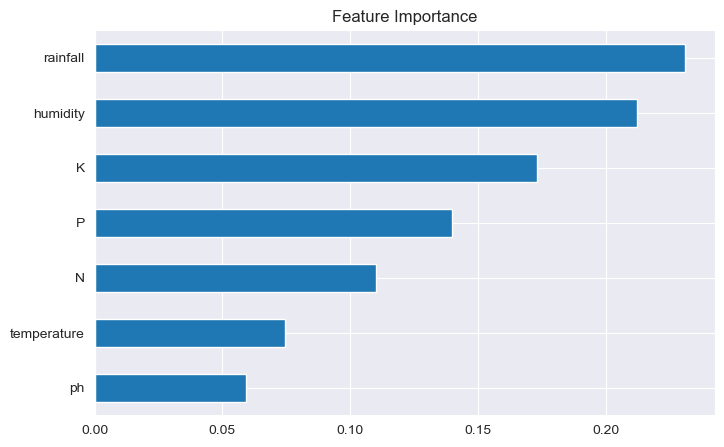

In [47]:
# Identifying feature importances to determine how much the features matter.
from sklearn.ensemble import RandomForestClassifier

X = df.drop("label", axis=1)
y = df["label"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()


- Most important features:
    * Rainfall
    * Humidity

- Least important features:
    * Temperature
    * pH

### Analysis of Mean Rainfall and Temperature by Crop

The groupby operation groups the data by crop labels and computes the mean values for rainfall and temperature, sorted in descending order by rainfall. Key insights:

- **High Rainfall Crops**: Crops like rice, coconut, and papaya have the highest average rainfall requirements (above 200 mm), indicating they thrive in wetter conditions.
- **Moderate Rainfall Crops**: Crops such as maize, banana, and mango fall in the mid-range (around 100-150 mm).
- **Low Rainfall Crops**: Chickpea, kidneybeans, and pigeonpeas require the least rainfall (below 100 mm), suggesting suitability for drier regions.
- **Temperature Trends**: Temperature averages range from about 20-30°C, with crops like rice and coconut preferring warmer, humid environments, while others like chickpea are more tolerant of moderate temperatures. This aligns with feature importance, where rainfall and humidity are key factors for crop recommendation.

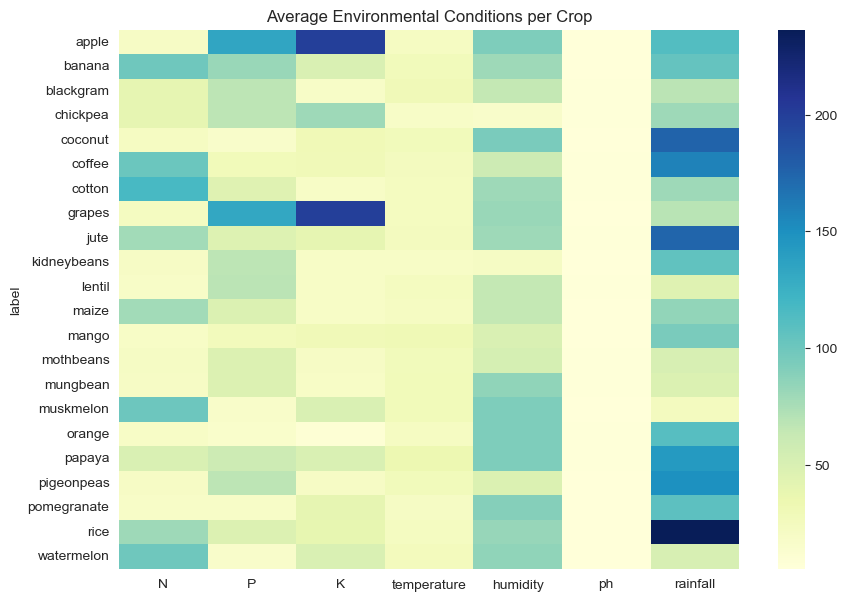

In [48]:
crop_summary = df.groupby("label").mean()
plt.figure(figsize=(10,7))
sns.heatmap(crop_summary, cmap="YlGnBu")
plt.title("Average Environmental Conditions per Crop")
plt.show()


Modelling.

In [53]:
# Modelling.
X = df.drop(columns=['label'], axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_pred, y_test)
print("Model accuracy is:", accuracy)

Model accuracy is: 0.9945454545454545


In [54]:
# Evaluating model.
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        25
      banana       1.00      1.00      1.00        25
   blackgram       1.00      0.96      0.98        25
    chickpea       1.00      1.00      1.00        25
     coconut       1.00      1.00      1.00        25
      coffee       1.00      1.00      1.00        25
      cotton       1.00      1.00      1.00        25
      grapes       1.00      1.00      1.00        25
        jute       0.96      1.00      0.98        25
 kidneybeans       1.00      1.00      1.00        25
      lentil       1.00      0.96      0.98        25
       maize       0.96      1.00      0.98        25
       mango       1.00      1.00      1.00        25
   mothbeans       0.96      1.00      0.98        25
    mungbean       1.00      1.00      1.00        25
   muskmelon       1.00      1.00      1.00        25
      orange       1.00      1.00      1.00        25
      papaya       1.00    

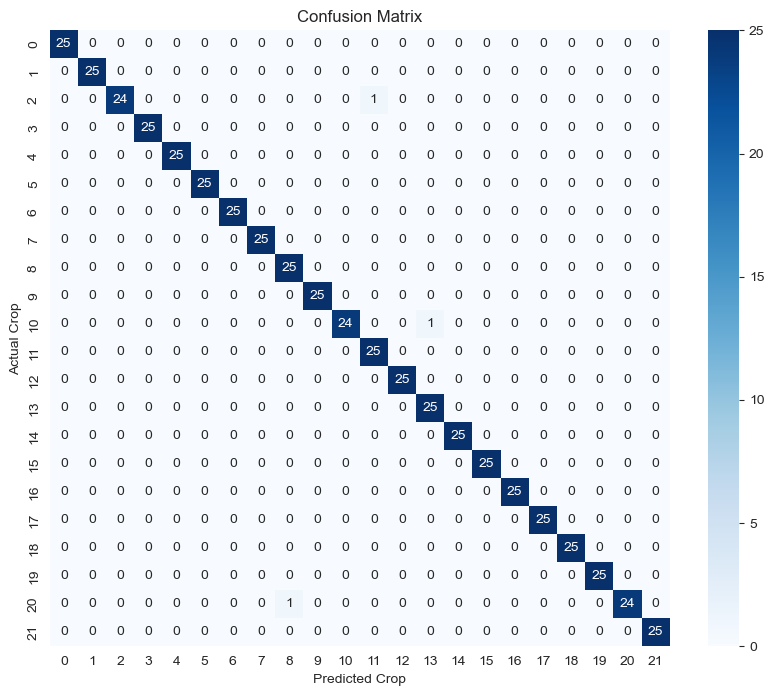

In [55]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual Crop")
plt.xlabel("Predicted Crop")
plt.show()

In [58]:
# Grid parameters.
param_grid ={
    "n_estimators": [100, 200, 300], # Number of trees.
    "max_depth": [None, 10, 20, 30], # Trees depth.
    "min_samples_split": [2, 5, 10], # minimum samples needed to split a node.
    "min_samples_leaf": [1, 2, 4] # minimum samples in a leaf node.
    }

grid_search = GridSearchCV(
    estimator= rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fitting to the grid.
grid_search.fit(X_train, y_train)

# Getting best model params.
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [59]:
# Using best model for prediction.
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Tuned accuracy:", accuracy_score(y_test, y_pred))

Tuned accuracy: 0.9945454545454545


In [60]:
# Saving the model.
import joblib
joblib.dump(best_model, "crop_model.pkl")

['crop_model.pkl']

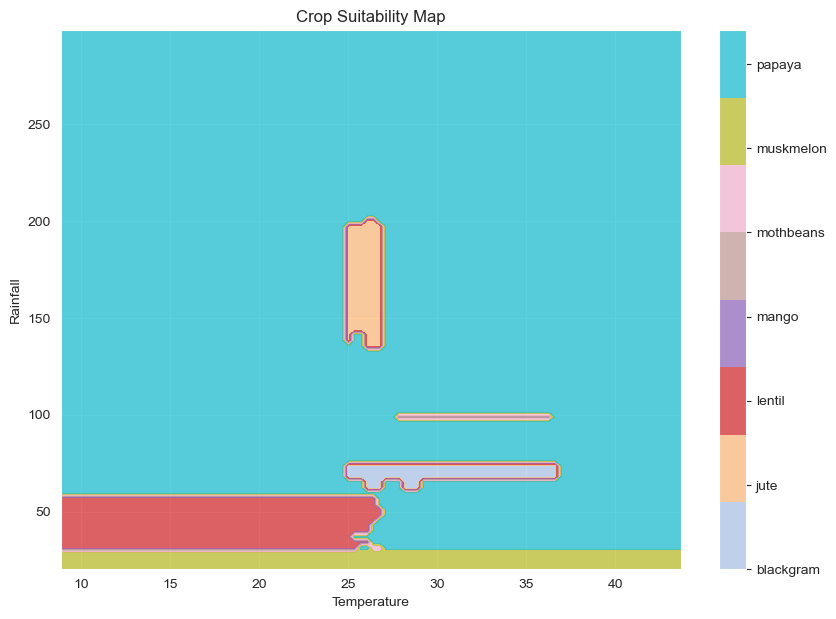

In [62]:
# Creating an environmental grid.
temp_range = np.linspace(df.temperature.min(), df.temperature.max(), 100)
rainfall_range = np.linspace(df.rainfall.min(), df.rainfall.max(), 100)

temp_grid, rainfall_grid = np.meshgrid(temp_range, rainfall_range)

# Building the prediction dataset.
grid_df = pd.DataFrame({
    "N": df.N.mean(),
    "P": df.P.mean(),
    "K": df.K.mean(),
    "temperature": temp_grid.ravel(),
    "humidity": df.humidity.mean(),
    "ph": df.ph.mean(),
    "rainfall": rainfall_grid.ravel()
})

# Predicting for each env. condition
predictions = rf_model.predict(grid_df)

# Encoding crop labels.
encoder = LabelEncoder()
encoded_predictions = encoder.fit_transform(predictions)

crop_map = encoded_predictions.reshape(temp_grid.shape)

plt.figure(figsize=(10,7))

contour = plt.contourf(temp_grid, rainfall_grid, crop_map, alpha=0.7, cmap="tab20")

plt.xlabel("Temperature")
plt.ylabel("Rainfall")
plt.title("Crop Suitability Map")
cbar = plt.colorbar(contour)

cbar.set_ticks(range(len(encoder.classes_)))
cbar.set_ticklabels(encoder.classes_)

plt.show()


In [75]:
input = pd.DataFrame({
    "N": 90,
    "P": 30,
    "K": 0,
    "temperature": 85,
    "humidity": 30,
    "ph": 1,
    "rainfall": 10
}, index=X.index)

input_pred = best_model.predict(input)
print("Predicted crop:", input_pred)

Predicted crop: ['muskmelon' 'muskmelon' 'muskmelon' ... 'muskmelon' 'muskmelon'
 'muskmelon']
